## CFG to PDA Converter

This conversion from a context-free grammar (CFG) to a pushdown automata (PDA) is inspired by the approach from Michael Sipser.

In [264]:
from automata.pda.npda import NPDA

In [265]:
from automata.pda.npda import NPDA
# NPDA which matches palindromes consisting of 'a's and 'b's
# (accepting by final state)
# q0 reads the first half of the word, q1 the other half, q2 accepts.
# But we have to guess when to switch.
npda = NPDA(
    states={'q0', 'q1', 'q2'},
    input_symbols={'a', 'b'},
    stack_symbols={'A', 'B', '#'},
    transitions={
        'q0': {
            '': {
                '#': {('q2', '#')},  # no change to stack
            },
            'a': {
                '#': {('q0', ('A', '#'))},  # push 'A' to stack
                'A': {
                    ('q0', ('A', 'A')),  # push 'A' to stack
                    ('q1', ''),  # pop from stack
                },
                'B': {('q0', ('A', 'B'))},  # push 'A' to stack
            },
            'b': {
                '#': {('q0', ('B', '#'))},  # push 'B' to stack
                'A': {('q0', ('B', 'A'))},  # push 'B' to stack
                'B': {
                    ('q0', ('B', 'B')),  # push 'B' to stack
                    ('q1', ''),  # pop from stack
                },
            },
        },
        'q1': {
            '': {'#': {('q2', '#')}},  # push '#' to (currently empty) stack
            'a': {'A': {('q1', '')}},  # pop from stack
            'b': {'B': {('q1', '')}},  # pop from stack
        },
    },
    initial_state='q0',
    initial_stack_symbol='#',
    final_states={'q2'},
    acceptance_mode='final_state'
)

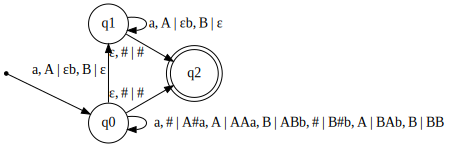

In [266]:
npda.show_diagram(layout_method="circo")

We will make a PDA for the following context-free language:
* S -> ATb | b
* A -> TA | ${\epsilon}$

In [267]:
grammar = {
    "S":["aTb", "b"],
    "A":["TA", "e"],
}

First, we add a novel character `$` to the stack, followed by the input character.

In [268]:
states={'qStart', 'q0', 'qLoop', 'qAccept'}

transitions = {
    'qStart': {
            '': {'': {('q0', '$')}},  # push '$' to (currently empty) stack
        },
    'q0': {
            '': {'': {('qLoop', 'S')}},  # push '#' to (currently empty) stack
        },
    'qLoop': {
            '': {'$': {('qAccept', '')}}
        },
}

Now, let's consider the particulars of our particular grammar.

In [269]:
state_index = 1

for variable, rules in grammar.items():
    for rule in rules:
        prev = "qLoop"
        for i in range(len(rule)-1):
            if prev not in transitions:
                transitions[prev] = {"":dict()}

            from_stack = variable if (i==0) else ""
            print(f"Made a transition from {prev} to q{state_index} on empty, pushing the character {from_stack} to the stack")
            transitions[prev][""][from_stack] = {(f'q{state_index}', rule[-i])}
            states.add(f'q{state_index}')
            prev = f'q{state_index}'

            state_index += 1

        if prev not in transitions:
            transitions[prev] = {"":dict()}
        print(f"Made a transition from {prev} to qLoop on empty, pushing the character {rule[0]} to the stack")
        transitions[prev][""][""] = {(f'qLoop', rule[0])}

all_rules = [item for sublist in [rules for rules in grammar.values()] for item in sublist]
vars_and_terminals = list(set([item for sublist in all_rules for item in sublist]).union(set(grammar.keys())))
terminals = [x for x in vars_and_terminals if (x.islower() and x != 'e')]

for char in terminals:
    transitions["qLoop"][char] = {char:  {(f'qLoop', '')}}


Made a transition from qLoop to q1 on empty, pushing the character S to the stack
Made a transition from q1 to q2 on empty, pushing the character  to the stack
Made a transition from q2 to qLoop on empty, pushing the character a to the stack
Made a transition from qLoop to qLoop on empty, pushing the character b to the stack
Made a transition from qLoop to q3 on empty, pushing the character A to the stack
Made a transition from q3 to qLoop on empty, pushing the character T to the stack
Made a transition from qLoop to qLoop on empty, pushing the character e to the stack


In [270]:
for key, item in transitions.items():
    print(key)
    for j,k in item.items():
        print(j, k)

qStart
 {'': {('q0', '$')}}
q0
 {'': {('qLoop', 'S')}}
qLoop
 {'$': {('qAccept', '')}, 'S': {('q1', 'a')}, '': {('qLoop', 'e')}, 'A': {('q3', 'T')}}
b {'b': {('qLoop', '')}}
a {'a': {('qLoop', '')}}
q1
 {'': {('q2', 'b')}}
q2
 {'': {('qLoop', 'a')}}
q3
 {'': {('qLoop', 'T')}}


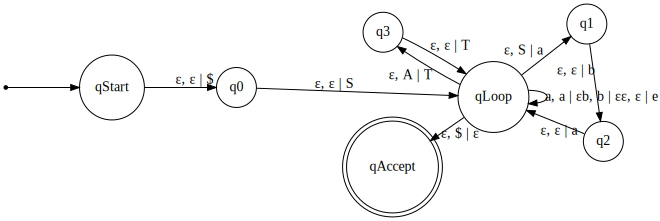

In [277]:
npda = NPDA(
    states=states,
    input_symbols=terminals,
    stack_symbols={'$', ''}.union(set(vars_and_terminals)),
    transitions=transitions,
    initial_state='qStart',
    initial_stack_symbol='$',
    final_states={'qAccept'},
    acceptance_mode='final_state'
)

npda.show_diagram(state_separation=4, layout_method="circo", fig_size=(500,500), path="output/pda_1.png")